In [ ]:
pip install pillow

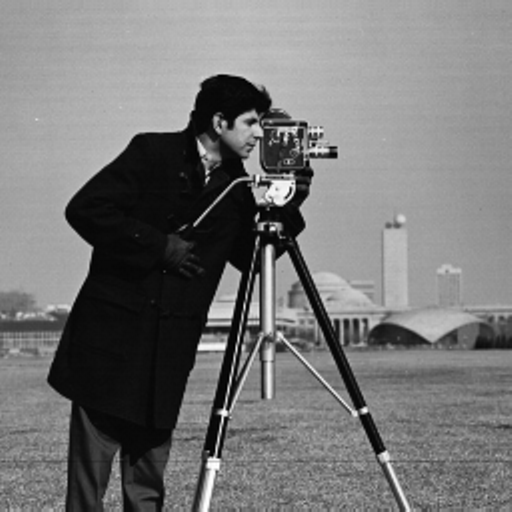

In [3]:
from PIL import Image
image_colored = Image.open ("/content/cameraman.png")
image_colored.show()
image_colored = Image.open("/content/cameraman.png")
display(image_colored)

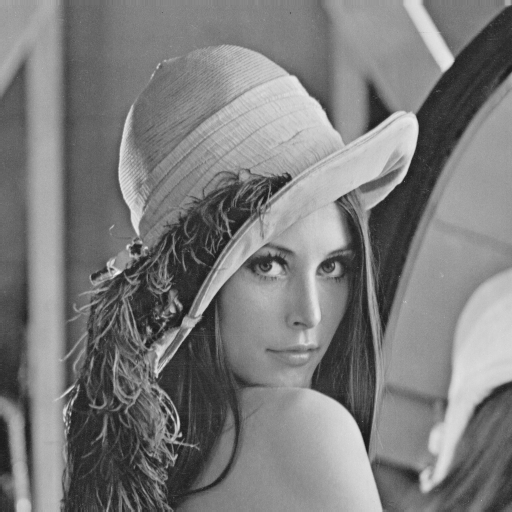

Image Format: GIF
Image Size: (512, 512)
Image Mode: P


In [4]:
from PIL import Image
image_grayed = Image.open("/content/lena_gray.gif")

display(image_grayed)
print("Image Format:" , image_grayed.format)
print("Image Size:" , image_grayed.size)
print("Image Mode:" , image_grayed.mode)


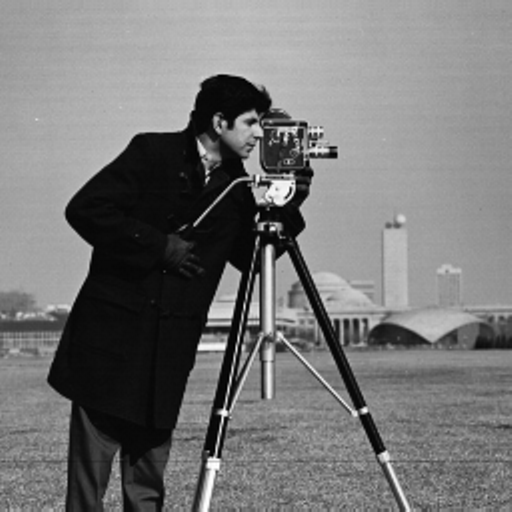

Image Format: PNG
Image Size: (512, 512)
Image Mode: L


In [5]:
image_colored = Image.open("/content/cameraman.png")
display(image_colored)
print("Image Format:" , image_colored.format)
print("Image Size:" , image_colored.size)
print("Image Mode:" , image_colored.mode)

In [6]:
width, height = image_grayed.size
channels = len(image_grayed.getbands())
print(f"Image shape (RGB): ({height},{width},{channels})")
image_size_grayed = width*height*1
print (f"Image size (RGB):{image_size_grayed}")

Image shape (RGB): (512,512,1)
Image size (RGB):262144


In [7]:
width, height = image_colored.size
channels = len(image_colored.getbands())
print(f"Image shape (RGB): ({height},{width},{channels})")
image_size_colored = width*height*3
print (f"Image size (RGB):{image_size_colored}")

Image shape (RGB): (512,512,1)
Image size (RGB):786432


In [8]:
import numpy as np
image_array_colored = np . array ( image_colored )
print (" Shape of the image array :", image_array_colored .
shape )

print("Shape of the image array:",image_array_colored.shape)


 Shape of the image array : (512, 512)
Shape of the image array: (512, 512)


In [9]:
import numpy as np
image_array_grayed = np . array ( image_grayed )
print (" Shape of the image array :", image_array_grayed .
shape )

print("Shape of the image array:",image_array_grayed.shape)

 Shape of the image array : (512, 512)
Shape of the image array: (512, 512)


Shape of the image array : (512, 512)
[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


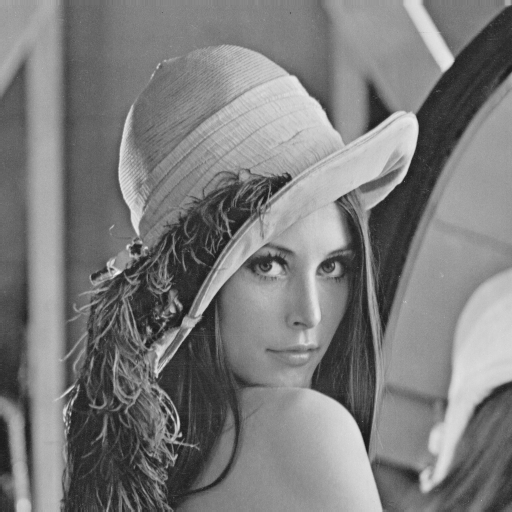

[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


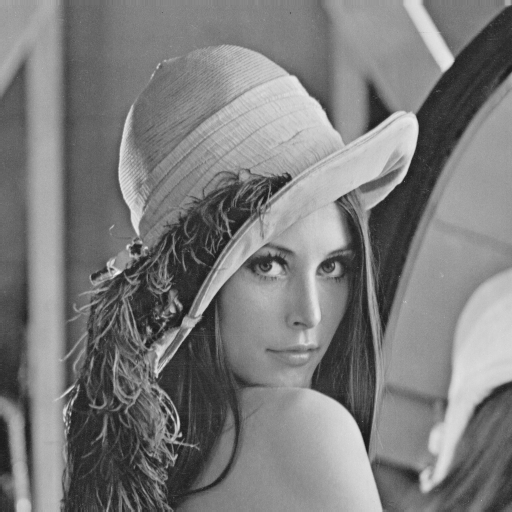

[[116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 [116 116 116 ... 112  11 133]
 ...
 [ 77  77 177 ... 145 147 148]
 [183 183  65 ... 145  36 143]
 [183 183  65 ... 145  36 143]]


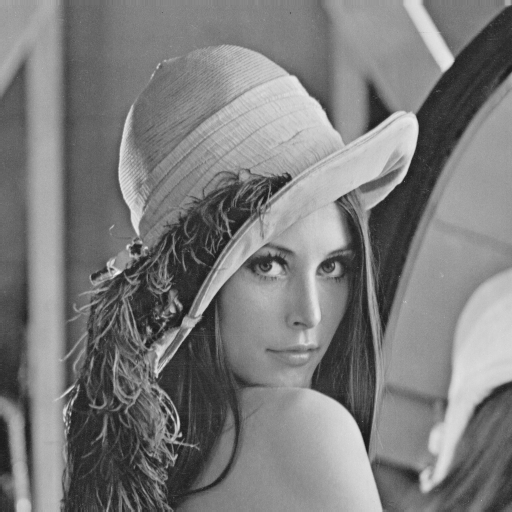

In [10]:
image_array_grayed = np.array(image_grayed)

print("Shape of the image array :", image_array_grayed.shape)


red_channel = image_array_grayed
print(red_channel)
display(image_grayed)

green_channel = image_array_grayed
print(green_channel)
display(image_grayed)

blue_channel = image_array_grayed
print(blue_channel)
display(image_grayed)

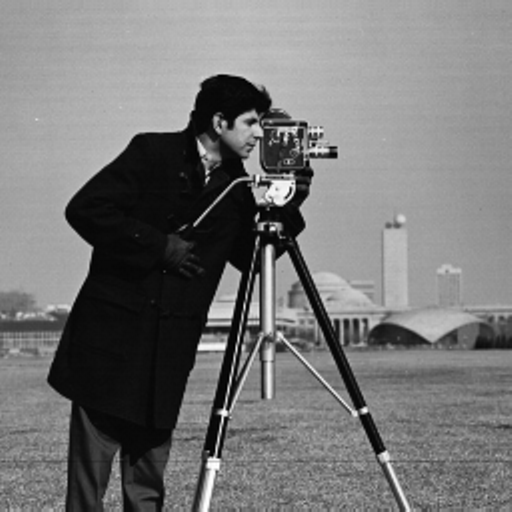

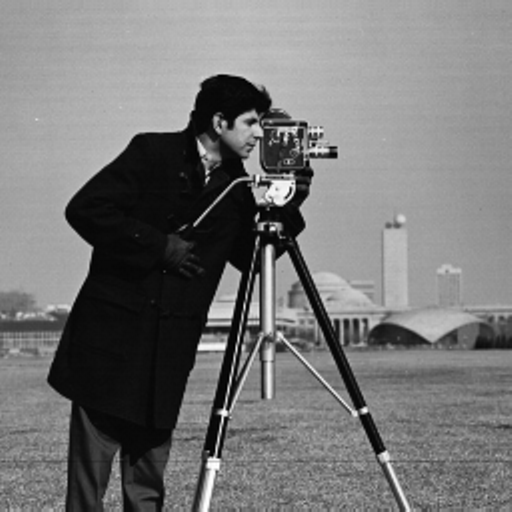

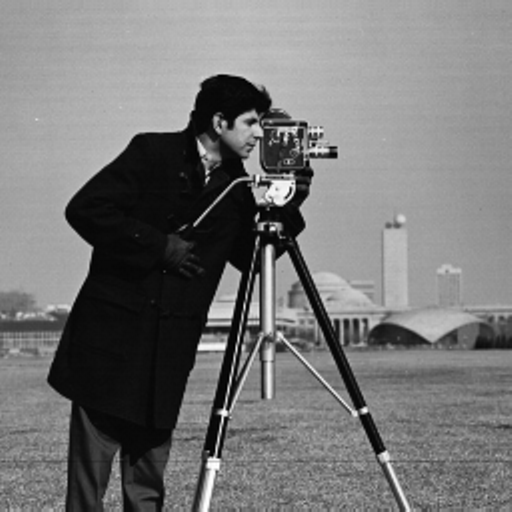

In [12]:
from PIL import Image

# Force convert to RGB before splitting
image_colored = image_colored.convert("RGB")

# Now split works correctly
r, g, b = image_colored.split()

# Display individual channels
display(r)
display(g)
display(b)

In [ ]:
import numpy as np

image_array = np.array(image_colored)

# Accessing a specific row - 100th row
row_100 = image_array[100, :, :]

# Accessing a specific column - 50th col
col_50 = image_array[:, 50, :]

# Accessing a specific pixel (row 10, col 20)
pixel = image_array[10, 20, :]  # Gets RGB values at (10, 20)

print("Row 100 shape:", row_100.shape)
print("Col 50 shape:", col_50.shape)
print("Pixel at (10,20) RGB values:", pixel)

Row 100 shape: (512, 3)
Col 50 shape: (512, 3)
Pixel at (10,20) RGB values: [158 158 158]


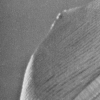

In [ ]:
# Define the cropping box (left, upper, right, lower)
left, upper, right, lower = 100, 50, 200, 150

# Crop the image
cropped_image = image_colored.crop((left, upper, right, lower))

# Display the cropped image
display(cropped_image)

In [ ]:
import numpy as np
from PIL import Image

# Create a black NumPy array (100x100 RGB image)
image_array = np.zeros((100, 100, 3), dtype=np.uint8)

# Convert the NumPy array back to a Pillow Image object
image_from_array = Image.fromarray(image_array)

# Display the image (use display() in Colab instead of show())
image_from_array.show()

# Optionally save the image to a file
image_from_array.save("output_image.jpg")


**PCA**

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

image = Image.open("/content/cameraman.png").convert("L")

image_array = np.array(image)

height, width = image_array.shape

data = image_array.reshape(height, width)

In [25]:
mean = np.mean(data, axis=0)

centered_data = data - mean

In [26]:
cov_matrix = np.cov(centered_data, rowvar=False)

In [27]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

sorted_indices = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_indices]

eigenvectors = eigenvectors[:, sorted_indices]

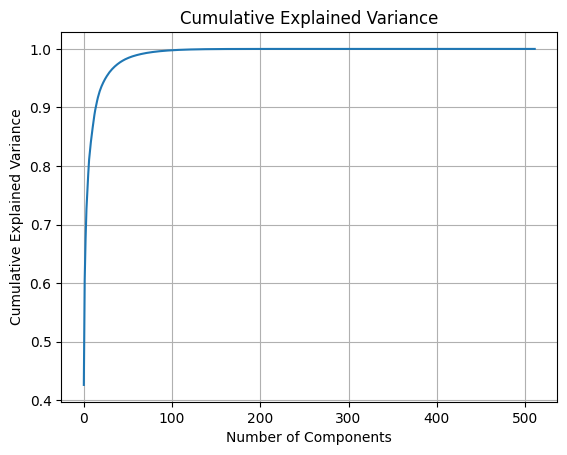

In [28]:
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

plt.plot(np.cumsum(explained_variance_ratio))

plt.title("Cumulative Explained Variance")

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [29]:
k = 50

components = eigenvectors[:, :k]

In [30]:
compressed_data = np.dot(centered_data, components)

In [31]:
decompressed_data = np.dot(compressed_data, components.T) + mean

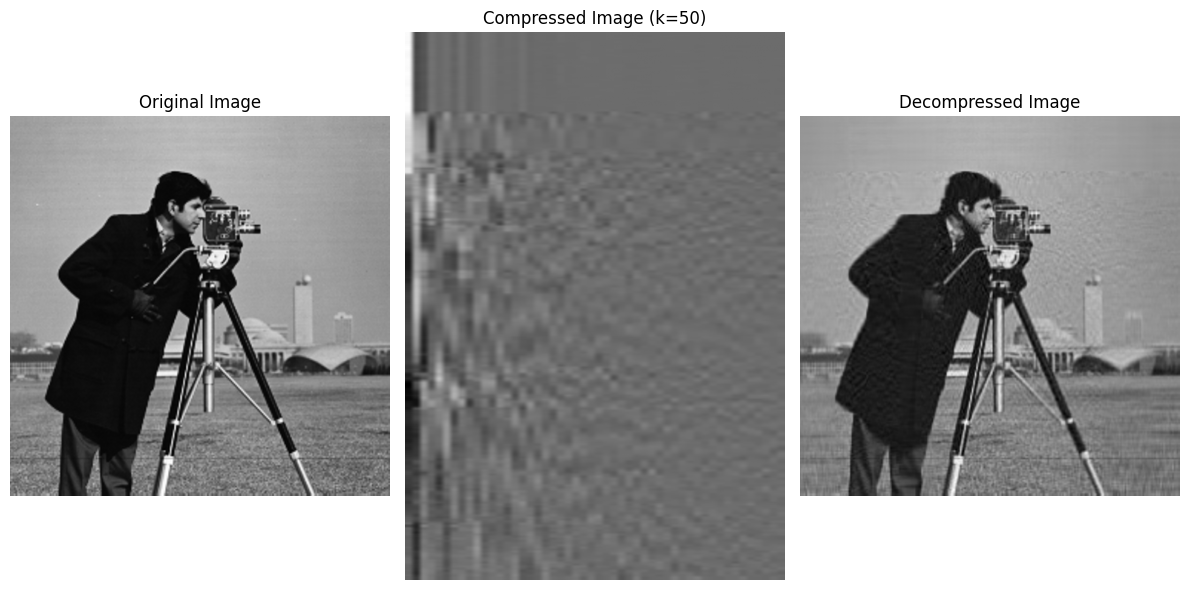

In [32]:
plt.figure(figsize=(12,6))

# original
plt.subplot(1,3,1)
plt.imshow(image_array, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# compressed
plt.subplot(1,3,2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

# decompressed
plt.subplot(1,3,3)
plt.imshow(decompressed_data, cmap="gray")
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()

plt.show()